In [ ]:
#This project focuses on preparing and analyzing a medical insurance dataset before applying machine learning models.
#The analysis includes data inspection, missing value detection, duplicate handling, correlation analysis, feature scaling, skewness analysis, and outlier detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
#Data Loading
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

insurance = pd.read_csv(url)

insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [44]:
insurance.to_csv("insurance.csv", index=False)

In [2]:
#Data Understanding
insurance.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:

insurance.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


In [4]:

insurance.shape

(1338, 7)

In [5]:

insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:

insurance.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [7]:

insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:

insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [43]:
#Data Cleaning
insurance["smoker"].unique()

array(['yes', 'no'], dtype=object)

In [10]:

insurance["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [11]:
insurance["sex"].value_counts()

,count
sex,
male,676
female,662


In [12]:
insurance["smoker"].value_counts()

,count
smoker,
no,1064
yes,274


In [13]:
insurance.duplicated().sum()

np.int64(1)

In [14]:
insurance.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [15]:
insurance.isnull().sum().sort_values(ascending=True)

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [16]:
num_cols = insurance.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    insurance[col].fillna(
        insurance[col].median(),
        inplace=True
    )

/tmp/ipykernel_1754/1139057652.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  insurance[col].fillna(


In [17]:

  cat_cols = insurance.select_dtypes(include=["object"]).columns

for col in cat_cols:
    insurance[col].fillna(
        insurance[col].mode()[0],
        inplace=True
    )

/tmp/ipykernel_1754/2260909960.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  insurance[col].fillna(


In [18]:
num_data=insurance.select_dtypes(include=["int64","float64"])

In [ ]:
#Exploratory Data Analysis

In [19]:
corr = num_data.corr()
corr
corr_target=corr["charges"].sort_values(ascending=False)
corr_target
corr_target[1:6]

,charges
age,0.299008
bmi,0.198341
children,0.067998


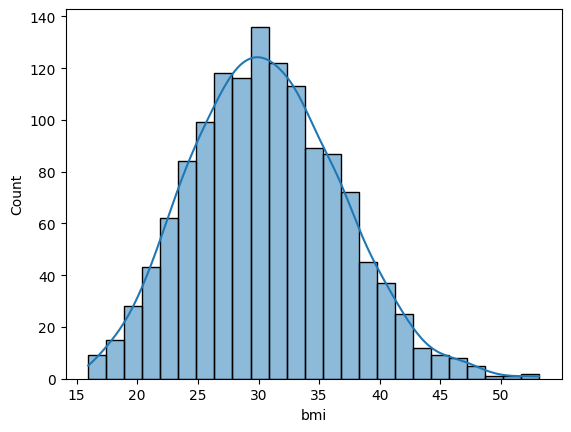

In [20]:
sns.histplot(insurance["bmi"],kde=True)
plt.show()

In [21]:
insurance["bmi"].skew()

np.float64(0.2840471105987448)

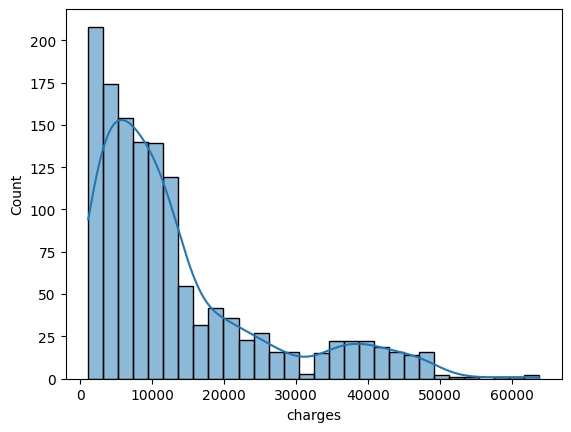

In [22]:
sns.histplot(insurance["charges"],kde=True)
plt.show()

In [ ]:
#Data Transformation

In [23]:
insurance["charges"].skew()

np.float64(1.5158796580240388)

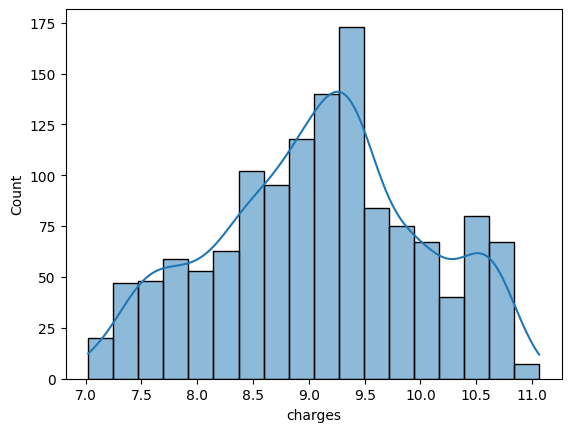

In [24]:
log_charges=np.log(insurance["charges"])
sns.histplot(log_charges,kde=True)
plt.show()

In [25]:
log_charges.skew()

np.float64(-0.09009752473024582)

In [26]:
insurance.duplicated().sum()
insurance.shape
insurance=insurance.drop_duplicates()
insurance.shape

(1337, 7)

In [27]:
scaler=MinMaxScaler()
insurance[["age","bmi"]]= scaler .fit_transform(insurance[["age","bmi"]])


In [28]:
std = StandardScaler()
insurance[["charges"]]=std.fit_transform(insurance[["charges"]])

<Axes: xlabel='charges'>

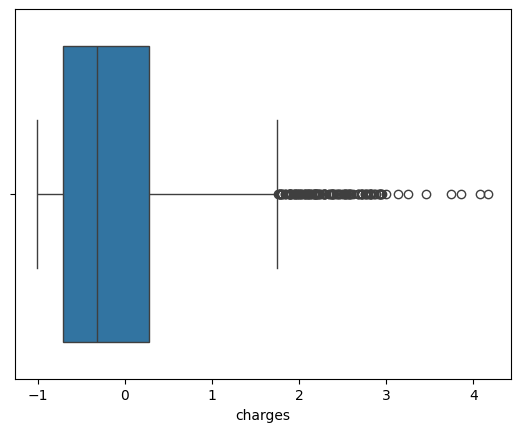

In [29]:
sns.boxplot(x=insurance["charges"])


In [ ]:
#Outlier Detection

In [30]:
insurance["Charge_Z"] = stats.zscore(
    insurance["charges"]
)

In [31]:
insurance = insurance[
    abs(insurance["Charge_Z"]) <= 3
]

In [32]:
insurance_clean = insurance[
    abs(insurance["Charge_Z"]) <= 3
]

In [33]:
insurance["charge_z"]=stats.zscore(insurance["charges"])

In [34]:
insurance[
    abs(
        insurance["Charge_Z"]
    ) > 3
]

,age,sex,bmi,children,smoker,region,charges,Charge_Z,charge_z


In [35]:
insurance[
    abs(
        insurance["Charge_Z"]
    ) > 3
]

,age,sex,bmi,children,smoker,region,charges,Charge_Z,charge_z


In [36]:
insurance = insurance[
    abs(
        insurance["Charge_Z"]
    ) <= 3
]

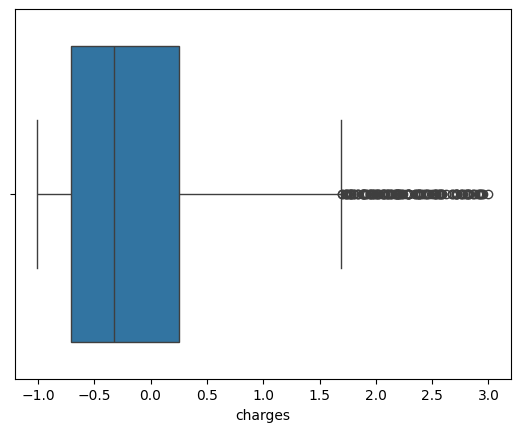

In [37]:
sns.boxplot(
    x=insurance["charges"]
)

plt.show()

<Axes: xlabel='age', ylabel='charges'>

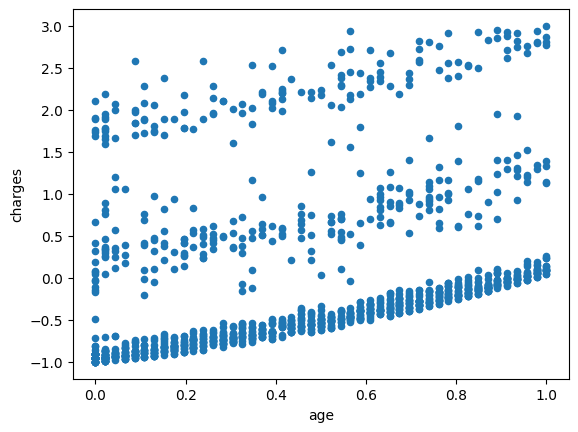

In [38]:
insurance.plot.scatter(x="age",y="charges")

<Axes: xlabel='bmi', ylabel='charges'>

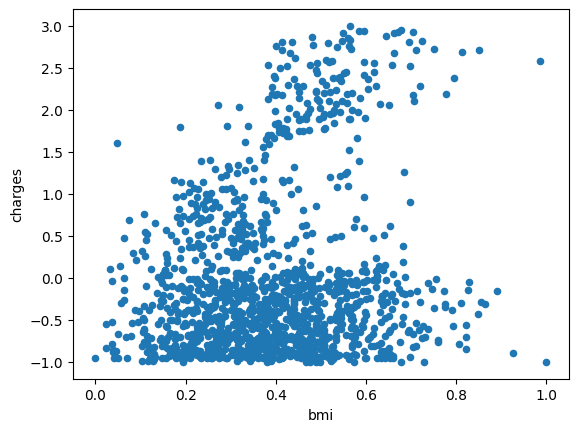

In [39]:
insurance.plot.scatter(x="bmi",y="charges")

In [40]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'Charge_Z', 'charge_z'],
      dtype='object')

In [41]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges,Charge_Z,charge_z
0,0.021739,female,0.321227,0,yes,southwest,0.297857,0.297857,0.328304
1,0.000000,male,0.479150,1,no,southeast,-0.954381,-0.954381,-0.967902
2,0.217391,male,0.458434,3,no,southeast,-0.729373,-0.729373,-0.734993
3,0.326087,male,0.181464,0,no,northwest,0.719104,0.719104,0.764343
4,0.304348,male,0.347592,0,no,northwest,-0.777499,-0.777499,-0.784809


In [42]:
insurance.columns.tolist()

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'region',
 'charges',
 'Charge_Z',
 'charge_z']

# Conclusion

This project focused on cleaning and exploring a real-world medical insurance dataset before applying any machine learning models.

During this analysis, I explored the dataset, identified duplicate records, checked for missing values, analyzed feature distributions, measured skewness, performed feature scaling using Min-Max Scaling and Standardization, examined correlations between numerical variables, and detected potential outliers using both visualization techniques and Z-score analysis.

This preprocessing workflow helps improve data quality, provides a better understanding of the dataset, and prepares the data for building reliable machine learning models.
